In [10]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

import matplotlib.ticker as mtick

In [11]:
df0 = pd.read_csv("Values0.csv")
df01 = pd.read_csv("Values0_1altalt.csv")
df1 = pd.read_csv("Values1.csv")
df2 = pd.read_csv("Values2.csv")
df21 = pd.read_csv("Values2_1alt.csv")
df3 = pd.read_csv("Values3.csv")

In [12]:
I0 = np.concat((df01["Gray_Value"].to_numpy(),df0["Gray_Value"].to_numpy()))
I1 = df1["Gray_Value"].to_numpy()
I2 = np.concat((df21["Gray_Value"].to_numpy(),df2["Gray_Value"].to_numpy()))
I3 = df3["Gray_Value"].to_numpy()

I2 = np.delete(I2,slice(45,55))

X0 = np.array(range(len(I0)))
X1 = np.array(range(len(I1)))
X2 = np.array(range(len(I2)))
X3 = np.array(range(len(I3)))

I = [I0, I1, I2, I3]
X = [X0, X1, X2, X3]

In [13]:
N = len(I)

peakIndex = [None] * N
peakData = [None] * N
peakWidths = [None] * N
peakWidthHeights = [None] * N
peakLeftIps = [None] * N
peakRightIps = [None] * N

valleyIndex = [None] * N
valleyData = [None] * N
valleyWidths = [None] * N
valleyWidthHeights = [None] * N
valleyLeftIps = [None] * N
valleyRightIps = [None] * N

distance = [15, 10, 7, 5]
prominence = [10, 10, 10, 0.2]

for i in range(len(I)):

    peakIndex[i], peakData[i] = scipy.signal.find_peaks(I[i], prominence=prominence[i], distance=distance[i])
    peakWidths[i], peakWidthHeights[i], peakLeftIps[i], peakRightIps[i] = scipy.signal.peak_widths(I[i], peakIndex[i], rel_height=0.1)

    valleyIndex[i], valleyData[i] = scipy.signal.find_peaks(-I[i], prominence = prominence[i], distance = distance[i])
    valleyWidths[i], valleyWidthHeights[i], valleyLeftIps[i], valleyRightIps[i] = scipy.signal.peak_widths(-I[i], valleyIndex[i], rel_height=0.1)

sampleSize = [(max(I[i])-min(I[i]))/len(I[i]) for i in range(len(I))]

peakErrors = [peakWidths[i]*sampleSize[i]/2 for i in range(len(I))]
valleyErrors = [valleyWidths[i]*sampleSize[i]/2 for i in range(len(I))]

peakIntensities = [I[i][peakIndex[i]] for i in range(len(I))]
peakPositions = [X[i][peakIndex[i]] for i in range(len(I))]

valleyIntensities = [I[i][valleyIndex[i]] for i in range(len(I))]
valleyPositions = [X[i][valleyIndex[i]] for i in range(len(I))]

In [14]:
elementPosition = [None] * len(I)

elementPosition[0] = [np.array(range(26,150)), np.array(range(205-2,314-2)),np.array(range(353,447)), np.array(range(488,570)), np.array(range(608,686)), np.array(range(712,782))]
elementPosition[1] = [np.array(range(22,82)), np.array(range(106,158)),np.array(range(179,226)), np.array(range(244,285)), np.array(range(304,341)), np.array(range(353,387))]
elementPosition[2] = [np.array(range(10,39)), np.array(range(52,79)), np.array(range(90,113)), np.array(range(124,145)), np.array(range(155,175)), np.array(range(181,200))]
elementPosition[3] = [np.array(range(9,24)), np.array(range(31,45)),np.array(range(50,62)), np.array(range(66,76)), np.array(range(81,91)), np.array(range(94,103))]

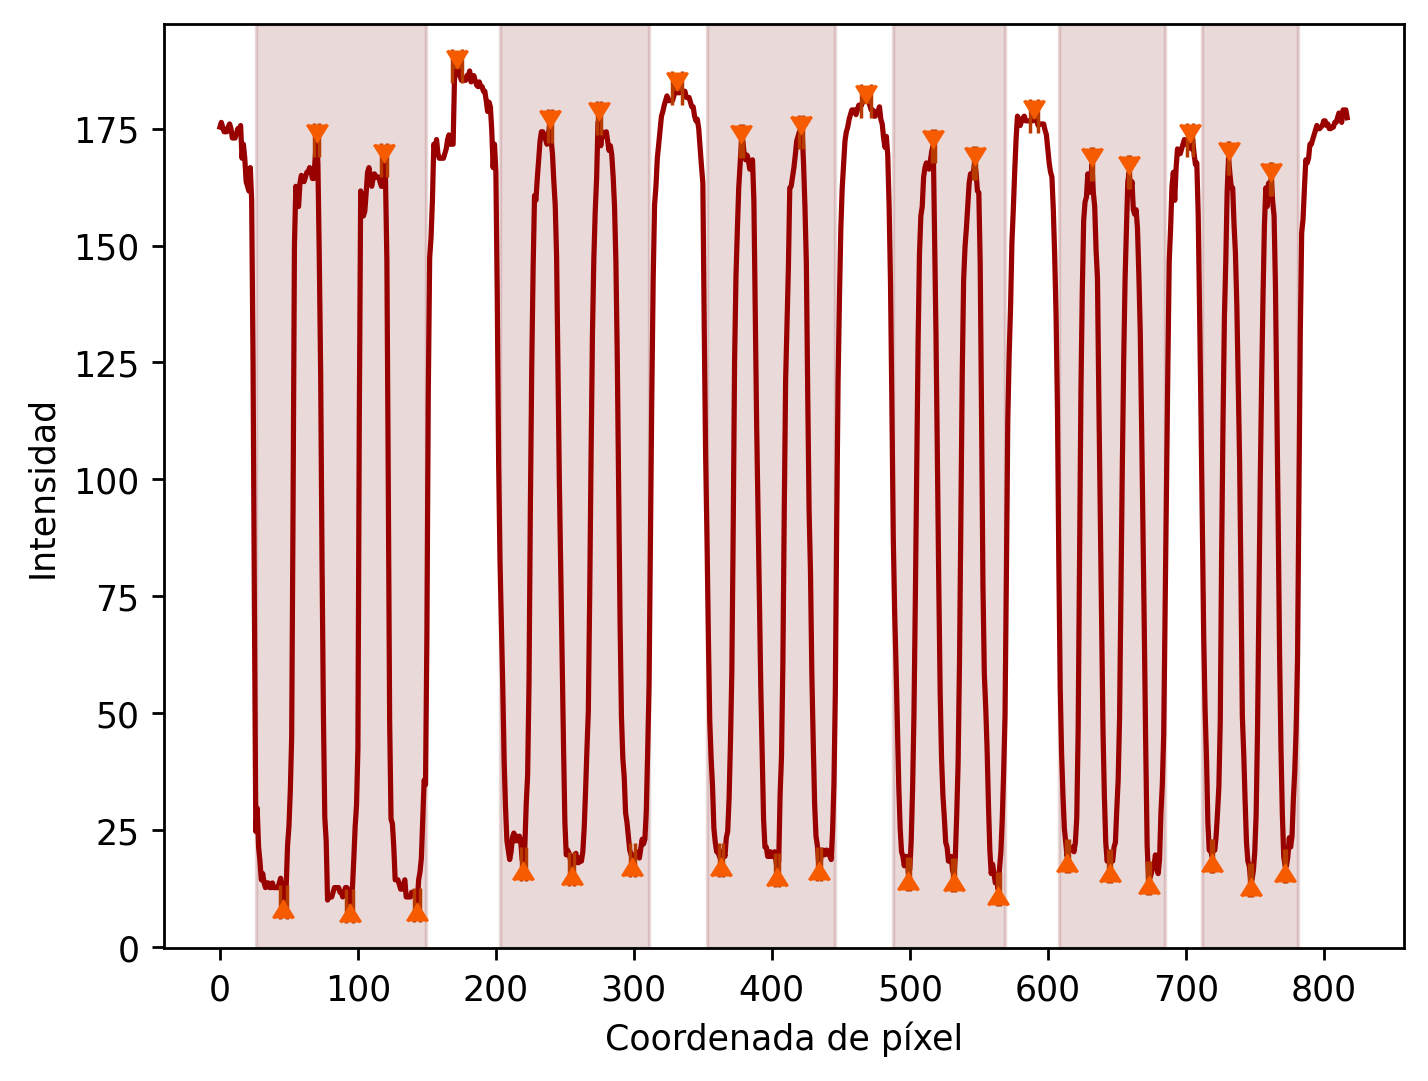

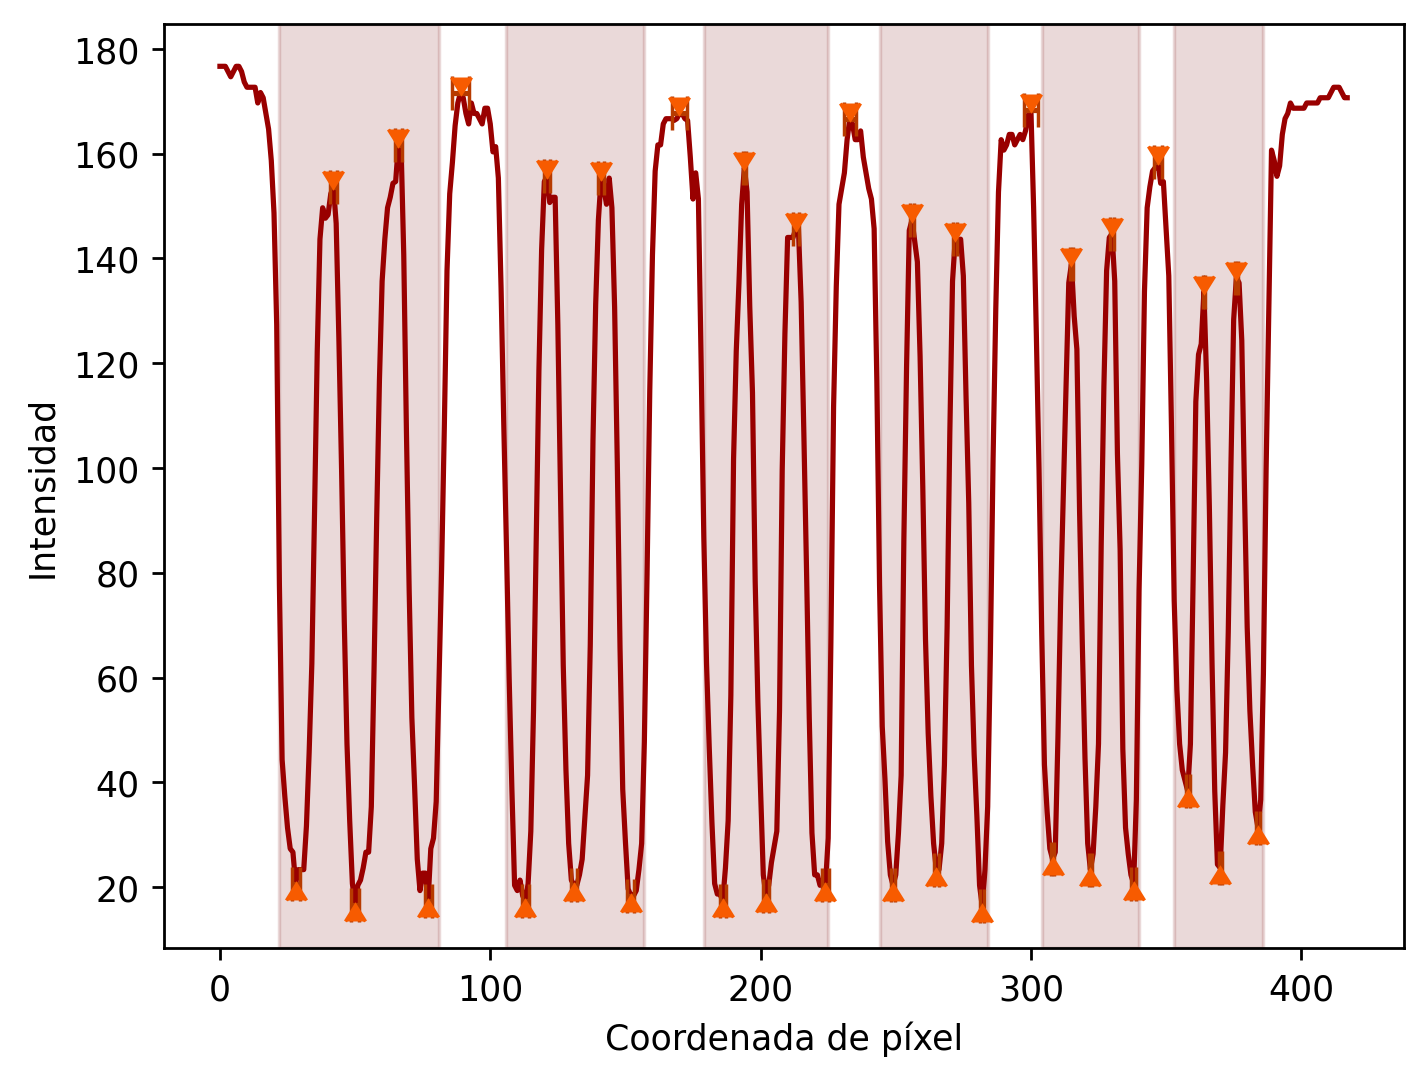

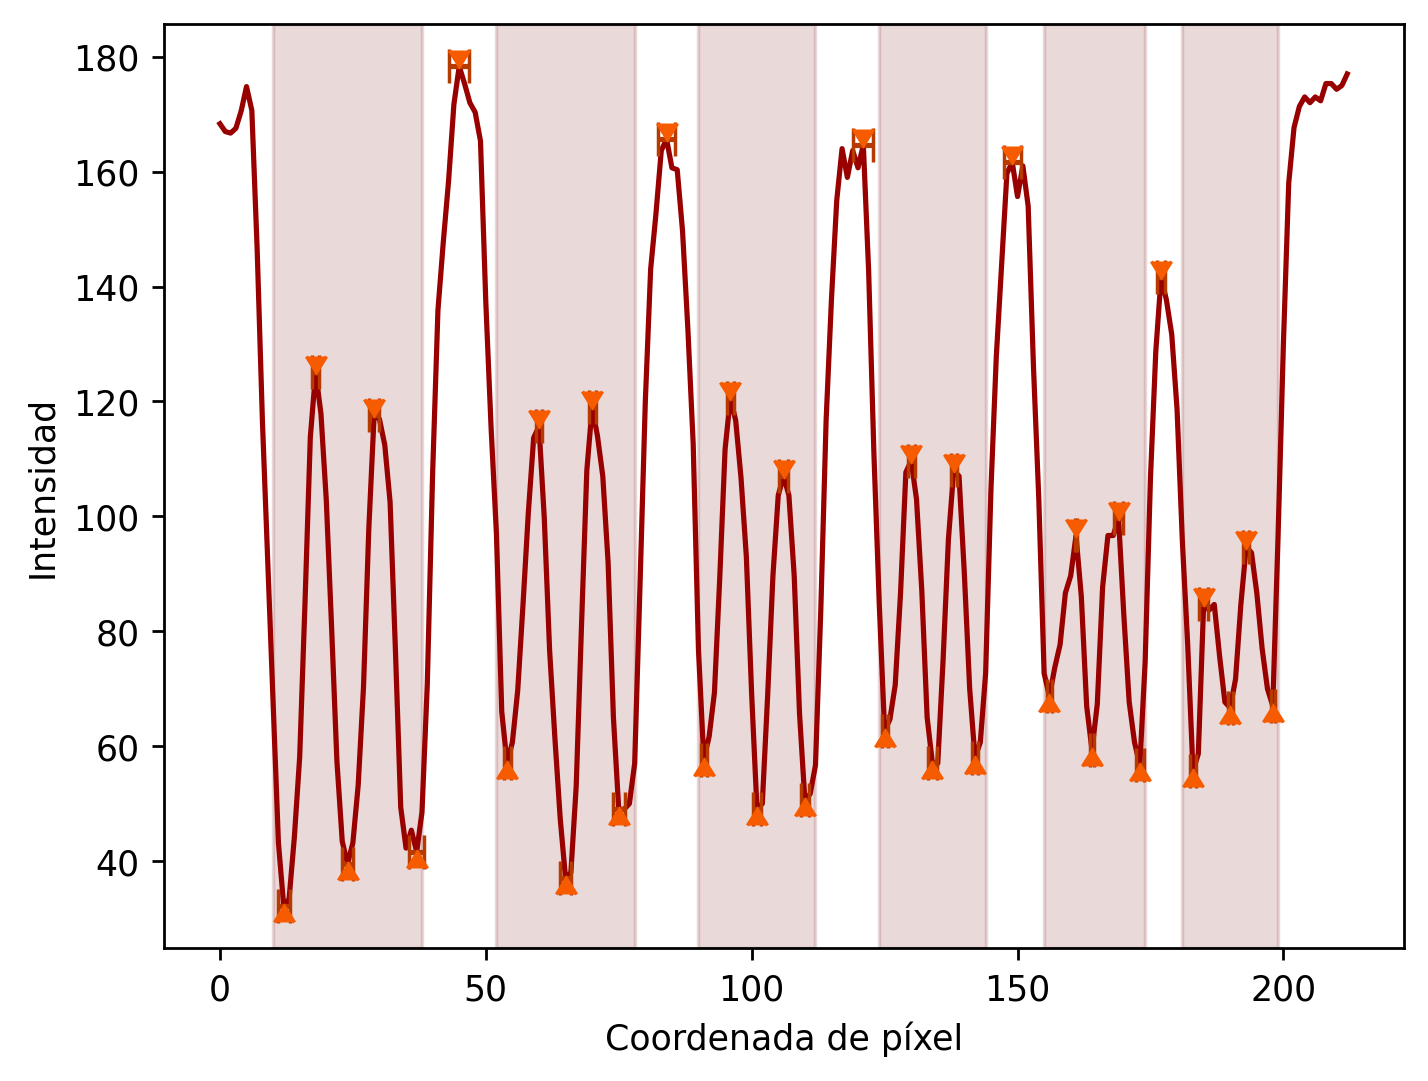

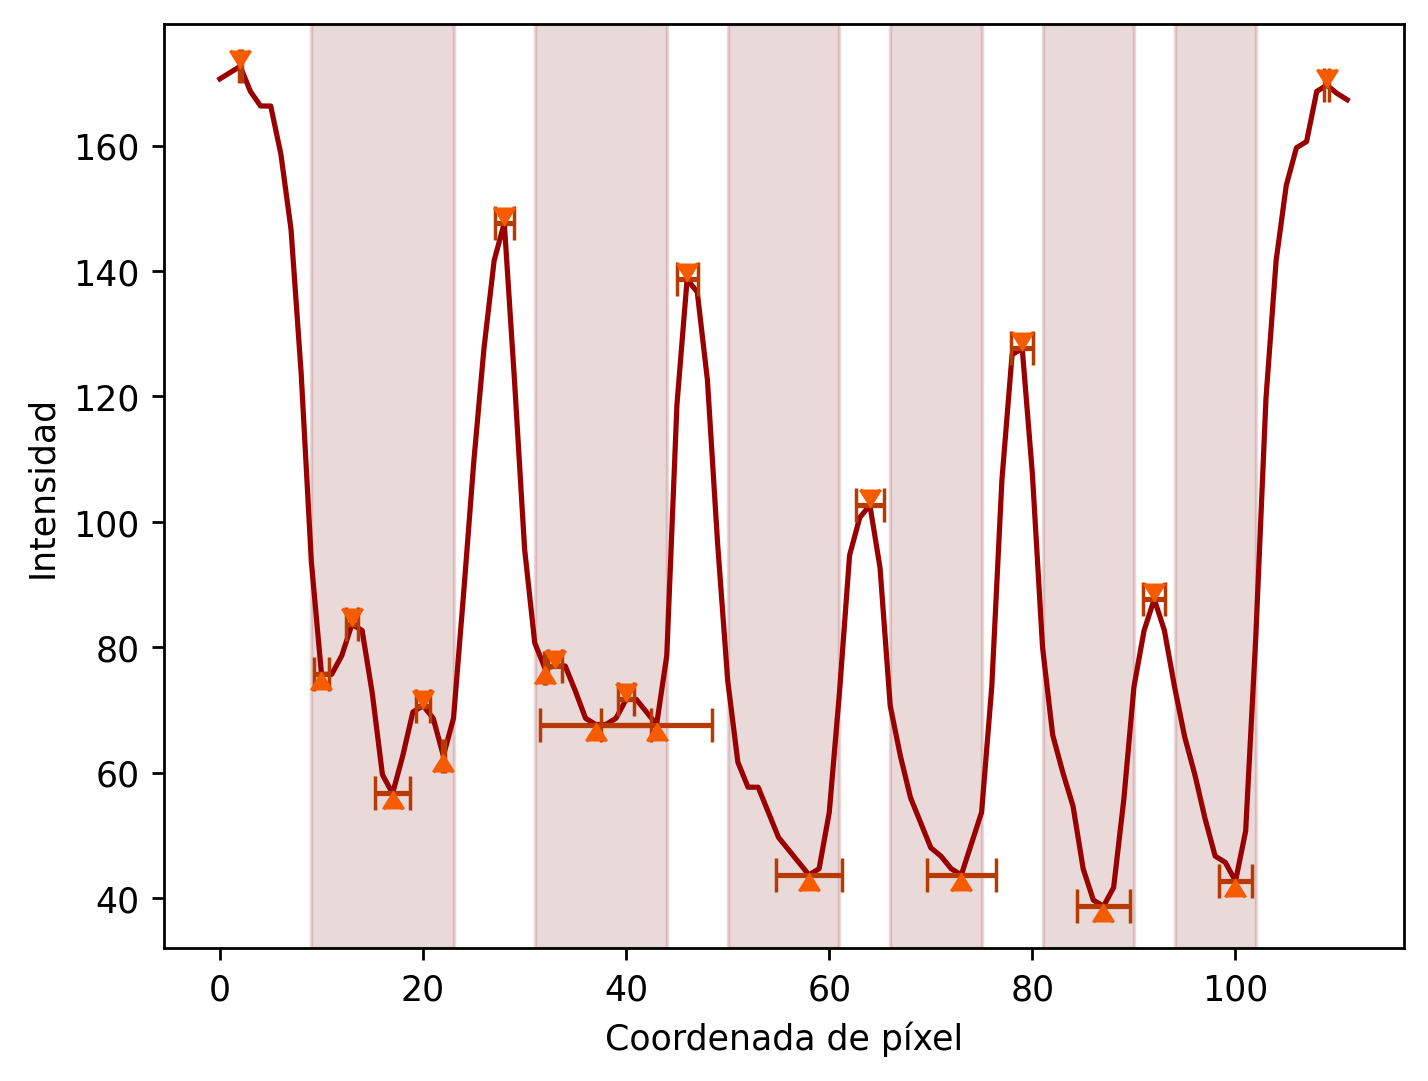

In [15]:
#group = 2

for group in range(len(I)):
    fig, ax = plt.subplots(dpi = 250)

    ax.plot(range(len(I[group])),I[group], color = "#990000")
    ax.errorbar(peakPositions[group], peakIntensities[group], marker = 7, color = "#f75b00", xerr = peakErrors[group], capsize= 5, zorder = 10, ls = "", ecolor = "#b73b00")
    ax.errorbar(valleyPositions[group], valleyIntensities[group], marker = 6, color = "#f75b00", xerr = valleyErrors[group], capsize = 5, zorder = 10, ls = "", ecolor = "#b73b00")


    for i in range(len(elementPosition[group])):
        ax.axvspan(min(elementPosition[group][i]), max(elementPosition[group][i]), alpha=0.15, color = "#770000")

        ax.set(xlabel = "Coordenada de píxel", ylabel = "Intensidad")

    plt.savefig(f"intensityPlot{group}.png", dpi = 250, bbox_inches = "tight")


    plt.show()



In [16]:
contrast = np.zeros((4,6))

for groupIndex in range(len(I)):
    for elementIndex in range(6):
        segment = elementPosition[groupIndex][elementIndex]

        peaksPositionIsInSegment = np.isin(peakIndex[groupIndex], segment)
        valleyPositionIsInSegment = np.isin(valleyIndex[groupIndex], segment)

        peakIntensitiesInSegment = peakIntensities[groupIndex][peaksPositionIsInSegment]
        valleyIntensitiesInSegment = valleyIntensities[groupIndex][valleyPositionIsInSegment]

        if not np.any(peaksPositionIsInSegment):
            contrast[groupIndex, elementIndex] = 0
        else:
            contrast[groupIndex, elementIndex] = (
                np.max(peakIntensitiesInSegment) - np.min(valleyIntensitiesInSegment)
            ) / (
                np.max(peakIntensitiesInSegment) + np.min(valleyIntensitiesInSegment)
            )

#contrast[0,0] = contrast[0,0] - 0.05
#contrast[2,0] = contrast[2,0] - 0.1

normalizedContrast = contrast/contrast[0,0]

MTF = normalizedContrast * np.pi / 4

flatMTF = MTF.flatten()

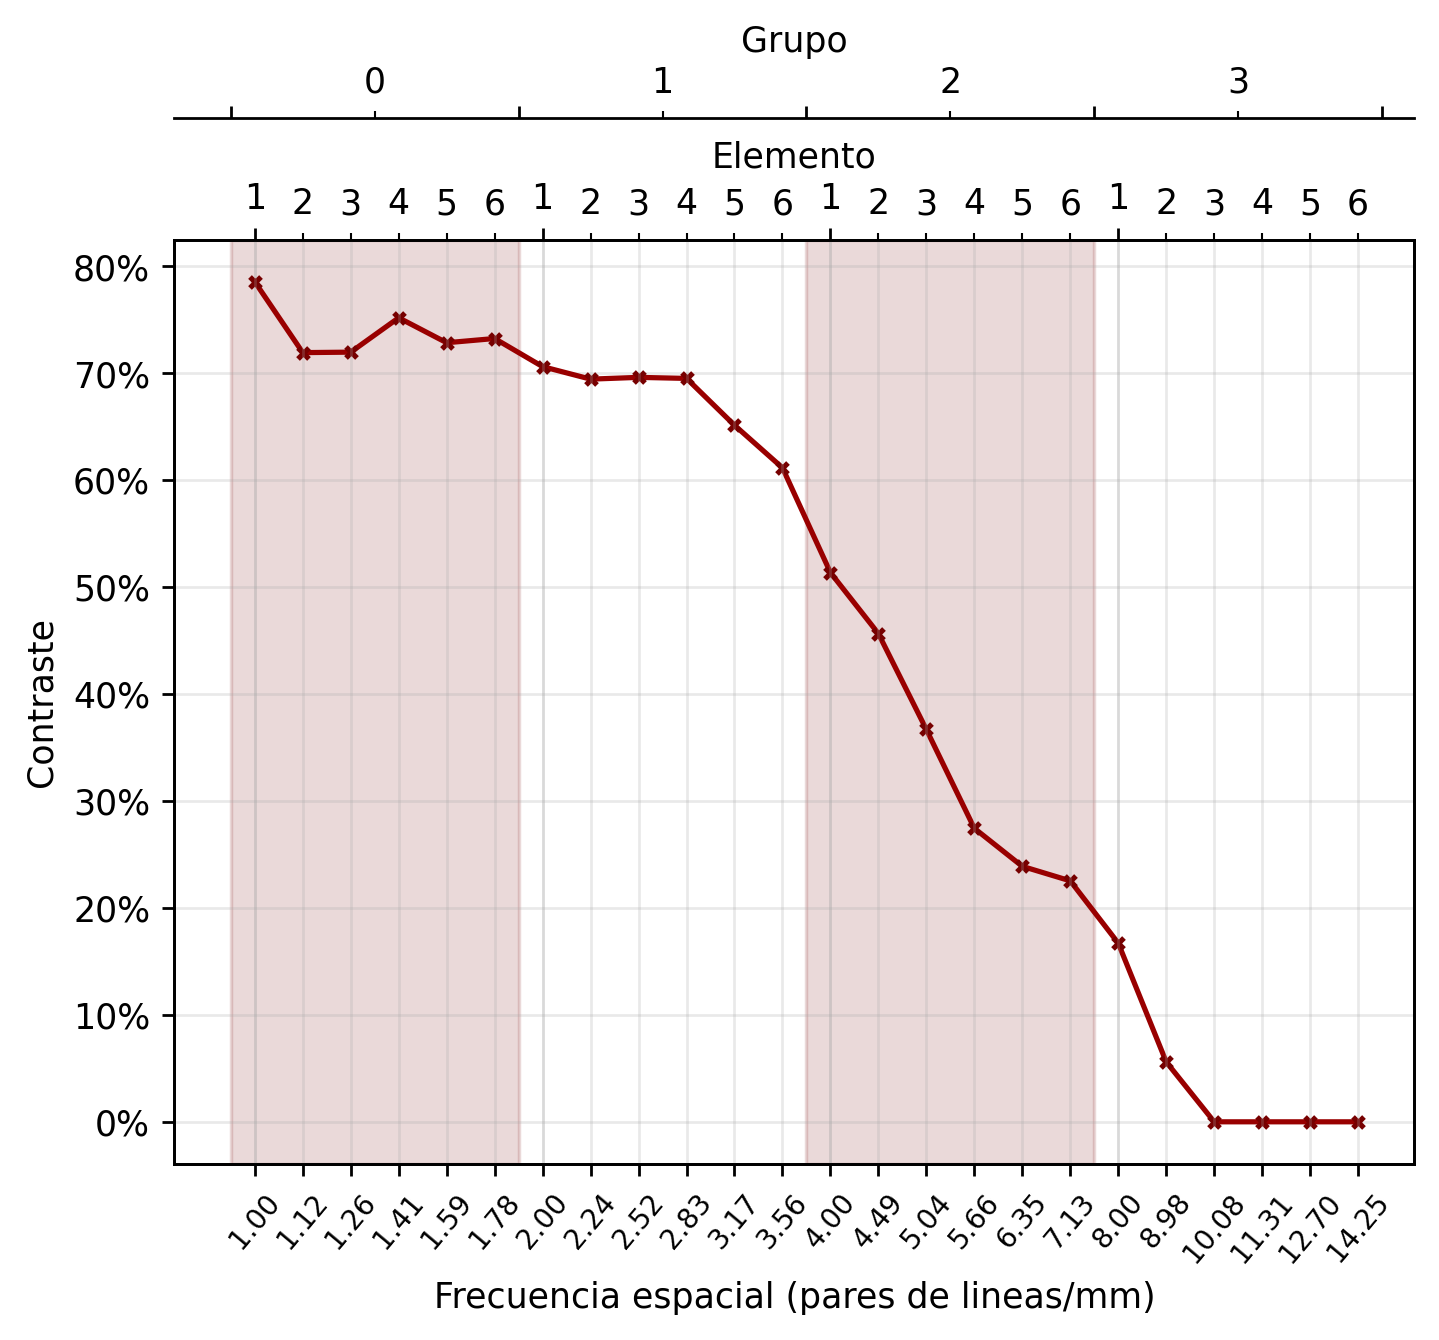

In [25]:
fig, ax = plt.subplots(dpi = 250)

ax.plot(range(len(flatMTF)), flatMTF, color = "#990000", zorder = 5)
ax.scatter(range(len(flatMTF)), flatMTF, color = "#770000", marker = "x", s = 10, zorder = 10)


#for i in range(5):
#    ax.vlines(i*6-0.5,0,0.78, color = "#AAAAAA", ls = "--", zorder = 0)

#y ticks

# ----------------------------
# LOWER LEVEL: detailed ticks
# ----------------------------

major_positions = np.arange(0, 24, 6)
ax.set_xticks(major_positions)
ax.set_xticklabels(['1'] * len(major_positions))

all_positions = np.arange(24)
minor_positions = [i for i in all_positions if i not in major_positions]
minor_labels = [(i % 6) + 1 for i in minor_positions]

ax.set_xticks(minor_positions, minor=True)
ax.set_xticklabels(minor_labels, minor=True)

ax.tick_params(axis='x', which='minor', labelsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax = 1))

# -------------------------
# ALTERNATING SHADING
# -------------------------
for i in range(0, 24, 6):
    if (i // 6) % 2 == 0:
        ax.axvspan(i - 0.5, i + 5.5, alpha=0.15, color = "#770000")

# ----------------------------
# UPPER LEVEL: group labels
# ----------------------------

ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())

group_centers = [2.5, 8.5, 14.5, 20.5]
group_labels = ['0', '1', '2', '3']

ax2.set_xticks(group_centers, minor=True)
ax2.set_xticklabels(group_labels, minor=True)

group_minor_edges = [i*6-0.5 for i in range(5)]
group_minor_labels = [None] * 5

ax2.set_xticks(group_minor_edges)
ax2.set_xticklabels(group_minor_labels)


#Another axes

ax3 = ax.twiny()
ax3.set_xlim(ax.get_xlim())

spatialFrequencies = [np.pow(2,i/6) for i in range(24)]

ax3.set_xticks(range(24))
ax3.set_xticklabels([f"{x:.2f}" for x in spatialFrequencies])
ax3.tick_params(axis='x', rotation= 50, labelsize=8)



# Move the second axis to bottom (so it sits above or below as desired)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

ax2.xaxis.set_ticks_position('top')
ax2.xaxis.set_label_position('top')

ax3.xaxis.set_ticks_position('bottom')
ax3.xaxis.set_label_position('bottom')

# Offset spine so it doesn't overlap
ax.spines['top'].set_position(('outward', 0))
ax2.spines['top'].set_position(('outward', 35))

# Clean up extra spines
ax2.spines['top'].set_visible(True)
ax2.spines['bottom'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

ax.grid(color = "#AAAAAA", alpha = 0.25)
ax3.grid(color = "#AAAAAA", alpha = 0.25)

ax.set(xlabel = "Elemento", ylabel = "Contraste")
ax2.set(xlabel = "Grupo")
ax3.set(xlabel = "Frecuencia espacial (pares de lineas/mm)")


plt.savefig("MTF.png", dpi = 250, bbox_inches='tight')

plt.show()

In [1373]:
newlist = [np.mean(flatMTF[i:i+6]) for i in range(0, len(flatMTF), 6)]

In [1374]:
fig, ax = plt.subplots(dpi = 250)

ax.plot(range(len(newlist)), newlist, color = "#990000")

for i in range(5):
    ax.vlines(i-0.5,0,0.78)

plt.close()

<function matplotlib.pyplot.show(close=None, block=None)>

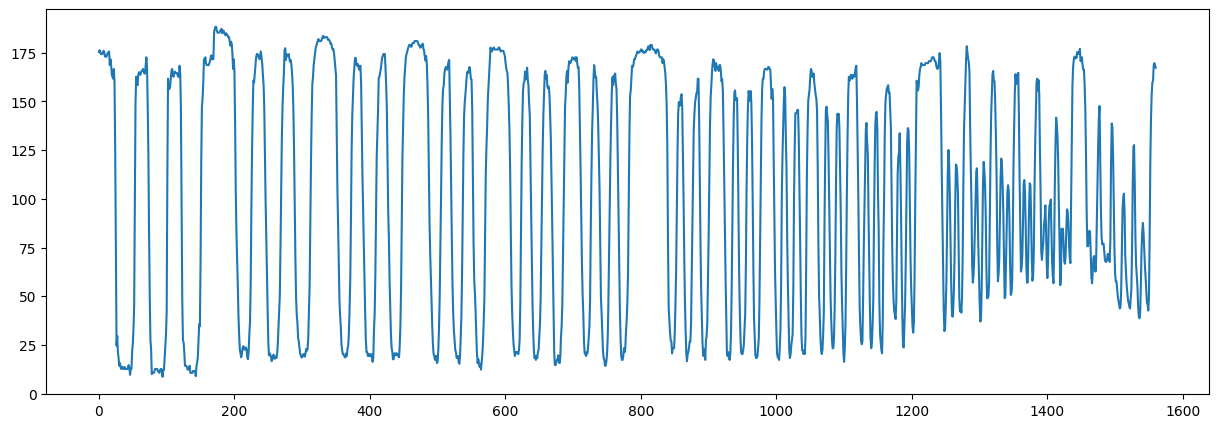

In [1375]:
fig, ax = plt.subplots(figsize = (15, 5))

ax.plot(range(len(np.concat((I0,I1,I2,I3)))), np.concat((I0,I1,I2,I3)))

plt.show